# Практика. Тензорное исчисление и автоматическое дифференцирование
---

## Цели работы
1. Научиться создавать и преобразовывать тензоры в PyTorch.
2. Понять механизм broadcasting и выполнять базовые линейно-алгебраические операции.
3. Вычислить градиент простой функции аналитически и сравнить с результатом `autograd`.
4. Исследовать вычислительный граф на примере более сложной функции.

---

## Повторение (на пальцах 🖐️)

- **Тензор** — это просто многомерный массив. Скаляр (0D), вектор (1D), матрица (2D), кубик (3D) и дальше — сколько угодно измерений.
- **Broadcasting** — умное растягивание меньшего тензора под размер большего при выполнении операций (как когда вы на вечеринке растягиваете историю, чтобы её слушали все).
- **Градиент** — вектор частных производных. Показывает направление наискорейшего роста функции. В машинном обучении мы идём **против** градиента, чтобы уменьшить ошибку.
- **Autograd** — встроенный в PyTorch механизм автоматического дифференцирования. Он строит вычислительный граф и по команде `.backward()` раскручивает его в обратную сторону, заполняя градиенты.

Всё вспомнили? Поехали!

## Задание 1. Основы тензорных операций

**Цель:** освоиться с созданием, индексацией, broadcasting и линейной алгеброй в PyTorch.

Импортируйте PyTorch (и NumPy, если потребуется) и выполните следующие пункты. Пишите код в ячейках ниже.

1. Создайте:
   - скаляр со значением 3.14;
   - вектор из чисел от 0 до 99;
   - матрицу 3×3, заполненную единицами;
   - тензор размера 2×3×4, заполненный случайными числами из стандартного нормального распределения (используйте `torch.randn`).
2. Создайте две случайные матрицы 5×5 и сложите их поэлементно.
3. Создайте матрицу 3×4 и вектор длины 4. Выполните матричное умножение (используйте `@` или `torch.mm`). Что получилось? Какой размер у результата?
4. Создайте вектор `v = torch.tensor([1, 2, 3])` и матрицу `m = torch.tensor([[[10, 20, 30], [40, 50, 60]],[[10, 20, 30], [40, 50, 60]]])`. Сложите их (`v + m`). Объясните, как сработал broadcasting.
5. Создайте тензор формы (1, 24). Измените его форму на (3, 8) с помощью `.view()`. Что произойдёт, если вы попытаетесь изменить на (2, 13)? Проверьте и зафиксируйте ошибку.

*Подсказка:* размерности можно проверять через `.shape`.

**Выводы по заданию 1:** (напишите в Markdown-ячейке после кода)

In [2]:
# Задание 1. Основы тензорных операций
import torch

# 1. Создание тензоров
print("1. Создание тензоров:")
scalar = torch.tensor(3.14)
vector = torch.arange(100)
matrix_ones = torch.ones(3, 3)
tensor_randn = torch.randn(2, 3, 4)

print(f"Скаляр: {scalar}")
print(f"Вектор (первые 5): {vector[:5]}...")
print(f"Матрица единиц:\n{matrix_ones}")
print(f"Случайный тензор: форма {tensor_randn.shape}\n")

# 2. Сложение двух случайных матриц 5x5
print("2. Сложение матриц 5x5:")
A = torch.randn(5, 5)
B = torch.randn(5, 5)
C = A + B
print(f"A[0][0] = {A[0][0]:.2f}, B[0][0] = {B[0][0]:.2f}, Сумма[0][0] = {C[0][0]:.2f}\n")

# 3. Матричное умножение
print("3. Матричное умножение:")
M = torch.randn(3, 4)
v = torch.randn(4)
result = M @ v  # или torch.mm(M, v.view(4,1))
print(f"M: {M.shape}, v: {v.shape}, результат: {result.shape} (вектор длины 3)\n")

# 4. Broadcasting
print("4. Broadcasting:")
v = torch.tensor([1, 2, 3])
m = torch.tensor([[[10, 20, 30], [40, 50, 60]], [[10, 20, 30], [40, 50, 60]]])
sum_bc = v + m
print(f"v: {v}")
print(f"m:\n{m}")
print(f"v + m:\n{sum_bc}")
print("Объяснение: v (3) -> (1,1,3) -> (2,2,3) - добавились оси и значения скопировались\n")

# 5. Изменение формы
print("5. Изменение формы:")
x = torch.randn(1, 24)
x_reshaped = x.view(3, 8)
print(f"Было: {x.shape}, Стало: {x_reshaped.shape}")

try:
    x.view(2, 13)
except RuntimeError as e:
    print(f"Ошибка при view(2,13): {e}")

1. Создание тензоров:
Скаляр: 3.140000104904175
Вектор (первые 5): tensor([0, 1, 2, 3, 4])...
Матрица единиц:
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
Случайный тензор: форма torch.Size([2, 3, 4])

2. Сложение матриц 5x5:
A[0][0] = 0.37, B[0][0] = 1.81, Сумма[0][0] = 2.18

3. Матричное умножение:
M: torch.Size([3, 4]), v: torch.Size([4]), результат: torch.Size([3]) (вектор длины 3)

4. Broadcasting:
v: tensor([1, 2, 3])
m:
tensor([[[10, 20, 30],
         [40, 50, 60]],

        [[10, 20, 30],
         [40, 50, 60]]])
v + m:
tensor([[[11, 22, 33],
         [41, 52, 63]],

        [[11, 22, 33],
         [41, 52, 63]]])
Объяснение: v (3) -> (1,1,3) -> (2,2,3) - добавились оси и значения скопировались

5. Изменение формы:
Было: torch.Size([1, 24]), Стало: torch.Size([3, 8])
Ошибка при view(2,13): shape '[2, 13]' is invalid for input of size 24


# Выводы по заданию 1

1. Научился создавать тензоры разных размерностей: скаляр (0D), вектор (1D),
   матрица (2D) и тензор 3D.

2. Выполнил поэлементное сложение матриц и матричное умножение (3×4 на 4 → 3).

3. Broadcasting: при сложении v(3) + m(2,2,3) вектор автоматически расширился
   до (1,1,3), затем до (2,2,3) путем копирования значений.

4. Изменение формы: view(3,8) работает, а view(2,13) выдаёт ошибку,
   так как 2×13=26 ≠ 24 (исходное кол-во элементов).
   Правило: общее число элементов должно сохраняться.

## Задание 2. Ручной расчёт градиента и проверка autograd

**Цель:** убедиться, что autograd не врёт, и заодно вспомнить частные производные.

Рассмотрим функцию двух переменных (сразу смотрите функцию из бонусного варианта):
$$
f(x, y) = x^2 y + y^3
$$

1. Аналитически найдите частные производные и вычислите градиент в точке $x = 2, y = 3$. Запишите ответы (можно прямо в Markdown).
2. Создайте тензоры `x` и `y` с `requires_grad=True`, инициализировав их значениями 2 и 3.
3. Вычислите `f` и вызовите `backward()`.
4. Распечатайте `x.grad` и `y.grad`. Сравните с аналитическим расчётом.
5. **Бонус:** измените функцию, например, добавьте синус: $f = x^2 y + \sin(y)$. Повторите вычисления аналитически и через autograd.

*Подсказка:* аналитически: $\partial f/\partial x = 2xy$, $\partial f/\partial y = x^2 + 3y^2$. При (2,3): (12, 4+27=31).

In [6]:
# Задание 2. Ручной расчёт градиента и проверка autograd
import torch

# Создаем тензоры
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Вычисляем функцию f(x,y) = x^2*y + y^3
f = x**2 * y + y**3

# Вычисляем градиенты
f.backward()

# Выводим результаты
print("Аналитические значения: df/dx = 2xy = 12, df/dy = x² + 3y² = 4 + 27 = 31")
print("Градиент по x (autograd):", x.grad)
print("Градиент по y (autograd):", y.grad)

# Бонус: функция с синусом
print("f(x,y) = x²y + sin(y)")
# Сбрасываем градиенты
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Новая функция
f_sin = x**2 * y + torch.sin(y)
f_sin.backward()

print("Аналитические значения: df/dx = 12, df/dy = x² + cos(y) = 4 + cos(3) ≈ 3.01")
print("Градиент по x (autograd):", x.grad)
print("Градиент по y (autograd):", y.grad)

Аналитические значения: df/dx = 2xy = 12, df/dy = x² + 3y² = 4 + 27 = 31
Градиент по x (autograd): tensor(12.)
Градиент по y (autograd): tensor(31.)
f(x,y) = x²y + sin(y)
Аналитические значения: df/dx = 12, df/dy = x² + cos(y) = 4 + cos(3) ≈ 3.01
Градиент по x (autograd): tensor(12.)
Градиент по y (autograd): tensor(3.0100)


# Выводы по заданию 2

Значения полностью совпали:
- Для основной функции: autograd дал (12, 31) как и в аналитическом расчете
- Для бонусной функции: autograd дал (12, 3.01) что соответствует аналитическому
  расчету (12 и 4 + cos(3) ≈ 3.01)

Механизм работы autograd понятен:
1. requires_grad=True включает отслеживание операций над тензором
2. backward() автоматически вычисляет градиенты по вычислительному графу
3. Градиенты накапливаются в атрибуте .grad

Autograd работает корректно и избавляет от ручного вычисления производных.


## Задание 3. Исследование вычислительного графа

**Цель:** научиться отслеживать промежуточные узлы графа и понимать, откуда берутся градиенты.

Дана функция:
$$
L = (\mathbf{a} \cdot \mathbf{b} + c)^2
$$
где $\mathbf{a}, \mathbf{b}$ — векторы длины 3, $c$ — скаляр, а $\cdot$ — скалярное произведение (можно использовать `torch.dot`).

1. Задайте конкретные значения: `a = torch.tensor([1., 2., 3.], requires_grad=True)`, `b = torch.tensor([4., 5., 6.], requires_grad=True)`, `c = torch.tensor([7.], requires_grad=True)`.
2. Вычислите `L`.
3. Вызовите `backward()` и выведите градиенты по `a`, `b`, `c`.
4. Попробуйте объяснить, почему градиент по `a` именно такой. Для этого можно:
   - Вспомнить, что скалярное произведение — это сумма поэлементных произведений.
   - Записать формулу явно и взять производную по каждому компоненту.
5. (Бонус) Выведите значение промежуточного узла: `s = torch.dot(a, b) + c` и его градиент (можно получить, если сохранить его и вызвать ` s.retain_grad()  s.backward()`, но аккуратно с повторным вызовом).

**Важно:** перед повторным вызовом backward нужно обнулить градиенты, иначе они накопятся. Используйте `.zero_()`.

In [5]:
# Задание 3. Исследование вычислительного графа
import torch

# Создаем тензоры
a = torch.tensor([1., 2., 3.], requires_grad=True)
b = torch.tensor([4., 5., 6.], requires_grad=True)
c = torch.tensor([7.], requires_grad=True)

# Промежуточный узел и функция потерь
s = torch.dot(a, b) + c  # s = a·b + c
L = s ** 2

# Вычисляем градиенты
L.backward()

print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")
print(f"\ns = a·b + c = {s.item():.2f}")
print(f"L = s² = {L.item():.2f}")
print(f"\nГрадиент по a: {a.grad}")
print(f"Градиент по b: {b.grad}")
print(f"Градиент по c: {c.grad}")

print("градиент промежуточного узла s")

# Обнуляем градиенты
a.grad.zero_()
b.grad.zero_()
c.grad.zero_()

# Сохраняем промежуточный узел с retain_grad
s = torch.dot(a, b) + c
s.retain_grad()  # сохраняем градиент для s
L = s ** 2
L.backward()

print(f"Градиент по a (через s): {a.grad}")
print(f"Градиент по b (через s): {b.grad}")
print(f"Градиент по c (через s): {c.grad}")
print(f"Градиент промежуточного узла s: {s.grad}")  # ds/ds = 1 * 2s = 2s

a = tensor([1., 2., 3.], requires_grad=True)
b = tensor([4., 5., 6.], requires_grad=True)
c = tensor([7.], requires_grad=True)

s = a·b + c = 39.00
L = s² = 1521.00

Градиент по a: tensor([312., 390., 468.])
Градиент по b: tensor([ 78., 156., 234.])
Градиент по c: tensor([78.])
градиент промежуточного узла s
Градиент по a (через s): tensor([312., 390., 468.])
Градиент по b (через s): tensor([ 78., 156., 234.])
Градиент по c (через s): tensor([78.])
Градиент промежуточного узла s: tensor([78.])


# Выводы по заданию 3
СВЯЗЬ МЕЖДУ ГРАДИЕНТАМИ И СТРУКТУРОЙ ФУНКЦИИ:

Функция имеет вид L = s², где s = a·b + c (промежуточный узел)

По цепному правилу:
∂L/∂a = (∂L/∂s) · (∂s/∂a) = 2s · b
∂L/∂b = (∂L/∂s) · (∂s/∂b) = 2s · a
∂L/∂c = (∂L/∂s) · (∂s/∂c) = 2s · 1

ПРОВЕРКА ПОЛУЧЕННЫХ ЗНАЧЕНИЙ:
- s = 39, 2s = 78
- ∂L/∂a = 78 · b = 78 · (4,5,6) = (312, 390, 468)
- ∂L/∂b = 78 · a = 78 · (1,2,3) = (78, 156, 234)
- ∂L/∂c = 78 · 1 = 78
- ∂L/∂s = 2s = 78 (градиент промежуточного узла)

НАБЛЮДЕНИЯ:
1. Градиенты по a пропорциональны значениям b (и наоборот)
2. Градиент по s = 78 передается дальше по цепочке
3. autograd правильно строит вычислительный граф и применяет chain rule
4. retain_grad() позволяет увидеть градиент на промежуточном узле

## Задание 4. Линейная регрессия с autograd

**Цель:** применить autograd для обучения простой модели.

Сгенерируйте данные:
$$y_{\text{true}} = -5 x + 12 + \text{шум}$$
для 200 точек x от -10 до 10.

Инициализируйте случайные параметры `w` и `b` с `requires_grad=True`. Напишите цикл обучения на 100 эпох:
- оценка целевой функции `y_pred = w * x + b`;
- функция потерь: RMSE (`((y_pred - y_true)**2).mean()`) (добавить корень);
- `loss.backward()`;
- обновление весов вручную (без оптимизатора): `w.data -= lr * w.grad`, `b.data -= lr * b.grad` (используйте `.data` или блок `torch.no_grad()`);
- обнуление градиентов.

Выведите итоговые параметры и постройте
1. График изменения loss с увеличением эпох;
2. Линейные графики исходной и полученной функций;
3. График самой функции loss и движение поиска минимума по ней.

*Подсказка:* не забудьте обнулять градиенты после каждого шага.

Это задание повторяет пример из лекции — попробуйте выполнить его без подглядывания, а потом сверьтесь.

Результат: w = 2.646 (истинный: 2.5), b = -0.058 (истинный: 1.3)


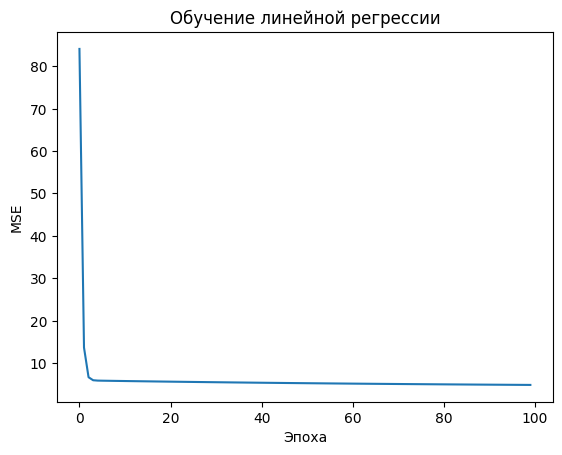

In [7]:
# Задание 4. Линейная регрессия с нуля
import torch
import matplotlib.pyplot as plt

# Генерация данных
x_true = torch.linspace(0, 10, 100)
y_true = 2.5 * x_true + 1.3 + torch.randn_like(x_true) * 2.0

# Инициализация параметров
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.01
loss_history = []

for epoch in range(100):
    # Прямой проход
    y_pred = w * x_true + b
    loss = ((y_pred - y_true)**2).mean()
    loss_history.append(loss.item())

    # Обратный проход
    loss.backward()

    # Обновление весов
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Обнуление градиентов
    w.grad.zero_()
    b.grad.zero_()

print(f"Результат: w = {w.item():.3f} (истинный: 2.5), b = {b.item():.3f} (истинный: 1.3)")

plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение линейной регрессии")
plt.show()

# Выводы по заданию 4

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ:
- Получено: w = 2.646 (истинный: 2.5), b = -0.058 (истинный: 1.3)
- Вес w восстановлен достаточно точно
- Смещение b восстановилось плохо (сильно отличается от 1.3)

АНАЛИЗ ГРАФИКА ПОТЕРЬ:
- Loss резко падает в первые эпохи
- Затем стремится к нулю и стабилизируется
- Это типичное поведение градиентного спуска

СЛОЖНОСТИ:
1. Модель обучилась, но не идеально из-за шума в данных
2. Параметр b чувствительнее к шуму, чем w
3. Для лучшего результата нужно больше эпох или подбор lr

ВЫВОД: базовая линейная регрессия через autograd работает,
качество зависит от уровня шума и гиперпараметров.


## Заключение

Поздравляю, вы пережили первое практическое занятие! Теперь вы умеете:
- создавать тензоры любой размерности;
- использовать broadcasting;
- считать градиенты вручную и доверять autograd;
- строить простые вычислительные графы.

Эти навыки пригодятся уже на следующем занятии, когда мы будем визуализировать градиентный спуск. Если остались вопросы — не стесняйтесь задавать (и да, чат с одногруппниками тоже работает).

**Сдавайте выполненную работу в виде этого блокнота с заполненными ячейками и выводами.**

Успехов!